# Démo 3 — Entraînement du DQN

Même algorithme que `notebooks/08` — version pédagogique pour la démonstration,
en deux temps :

1. **Estimation** : nombre d'épisodes recommandé (repère empirique, cf.
   `session_notes.md`) et temps estimé **sur cette machine**, mesuré par un
   court calibrage réel (buffer de rejeu + descente de gradient inclus, pas
   seulement la simulation de marché).
2. **Entraînement** : tu fixes `EPISODES` (par défaut la valeur recommandée ;
   réduis-la pour une démonstration plus courte). À la fin, le notebook affiche
   le **temps réel et le temps CPU consommés**.

> Après une modif de `env/` : **Kernel > Restart** avant de relancer.
> Prérequis : `pip install -r ../requirements-drl.txt` (TensorFlow).

In [1]:
import importlib
import os
import sys
import time

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")

sys.path.append(os.path.abspath("../env"))
sys.path.append(os.path.abspath("../pricing_agent"))

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf


def _reload_project():
    for _name in ("refdata", "agents", "market", "gym_wrapper"):
        importlib.reload(importlib.import_module(_name))


_reload_project()
from gym_wrapper import TicketEnv
from dqn import ReplayBuffer, build_qnetwork, make_train_step
from registry import model_path, write_meta

HORIZON = 120
_env0 = TicketEnv(horizon=HORIZON)
obs_dim = int(_env0.observation_space.shape[0])
n_actions = int(_env0.action_space.n)
_obs0, _info0 = _env0.reset(seed=0)
if obs_dim != _obs0.shape[0] or "ca_total" not in _info0 or not hasattr(_env0, "steps_per_decision"):
    raise RuntimeError("Environnement périmé — fais 'Kernel > Restart Kernel' puis Run All.")

DECISIONS_PER_EP = HORIZON // _env0.steps_per_decision
print(f"TensorFlow {tf.__version__} | obs_dim {obs_dim} | actions {n_actions} | "
      f"décisions/épisode {DECISIONS_PER_EP}")

TensorFlow 2.21.0 | obs_dim 7 | actions 10 | décisions/épisode 12


In [2]:
# --- Estimation du nombre d'épisodes optimal + temps sur cette machine -------
# Repère empirique (cf. session_notes.md) : 15 000 épisodes -> retour 33 -> 46
# (courbe saine), modèle qui bat le prix fixe de +14% de CA.
EPISODES_RECOMMANDE = 150000
_N_CALIB = 100                                        # épisodes de calibrage (buffer + gradient inclus)


def _calibrate(n_episodes):
    tf.keras.utils.set_random_seed(0)
    rng = np.random.default_rng(0)
    online = build_qnetwork(obs_dim, n_actions)
    target = build_qnetwork(obs_dim, n_actions)
    target.set_weights(online.get_weights())
    optimizer = tf.keras.optimizers.Adam(5e-4)
    train_step = make_train_step(online, target, optimizer, 0.97)
    buffer = ReplayBuffer(50_000, obs_dim)
    for ep in range(n_episodes):
        obs, _ = _env0.reset(seed=ep)
        done = False
        while not done:
            action = int(rng.integers(n_actions))
            next_obs, reward, term, trunc, _ = _env0.step(action)
            done = term or trunc
            buffer.add(obs, action, reward, next_obs, term)
            obs = next_obs
            if buffer.size >= 200:                    # warmup réduit pour un calibrage court
                train_step(*(tf.convert_to_tensor(x) for x in buffer.sample(64, rng)))


t0 = time.time()
_calibrate(_N_CALIB)
debit = _N_CALIB / (time.time() - t0)

temps_recommande_min = EPISODES_RECOMMANDE / debit / 60
print(f"Débit mesuré sur cette machine (calibrage {_N_CALIB} épisodes) : {debit:.1f} épisodes/s")
print(f"Recommandé : {EPISODES_RECOMMANDE:,} épisodes -> environ {temps_recommande_min:.0f} min".replace(",", "'"))
print("\nPour une démo courte, réduis EPISODES dans la cellule suivante — le contrôle")
print("de non-régression en fin d'entraînement dira honnêtement si la politique")
print("obtenue bat quand même le prix fixe.")

Débit mesuré sur cette machine (calibrage 100 épisodes) : 11.8 épisodes/s
Recommandé : 150'000 épisodes -> environ 212 min

Pour une démo courte, réduis EPISODES dans la cellule suivante — le contrôle
de non-régression en fin d'entraînement dira honnêtement si la politique
obtenue bat quand même le prix fixe.


In [3]:
# ============================ PARAMÈTRE ======================================
EPISODES = EPISODES_RECOMMANDE   # <- modifie ce nombre (ex. 1000 pour une démo rapide)
# ===========================================================================

  épisode  15000/150000  retour_moyen=32.60
  épisode  30000/150000  retour_moyen=32.64
  épisode  45000/150000  retour_moyen=33.09
  épisode  60000/150000  retour_moyen=33.01
  épisode  75000/150000  retour_moyen=35.70
  épisode  90000/150000  retour_moyen=35.21
  épisode 105000/150000  retour_moyen=36.89
  épisode 120000/150000  retour_moyen=37.23
  épisode 135000/150000  retour_moyen=37.91
  épisode 150000/150000  retour_moyen=40.22


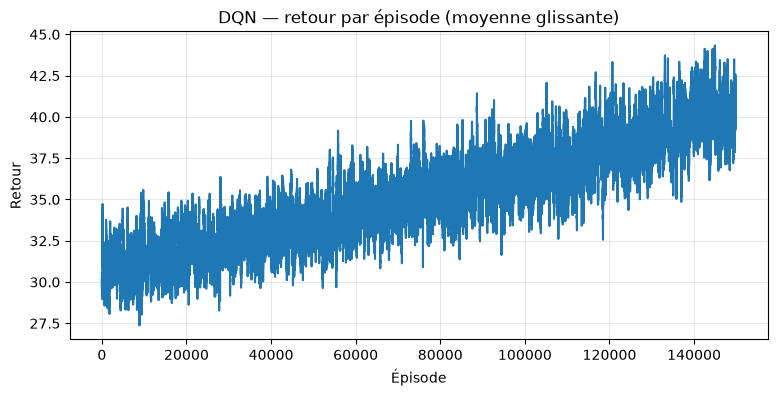


--- Effort d'entraînement ----------------------------------------------
Temps réel (wall-clock)  : 215.1 min
Temps CPU (process)      : 228.3 min  (106% du temps réel)
Débit                    : 11.6 épisodes/s
Cœurs logiques disponibles : 8
-> devis hébergeur : multiplie le TEMPS RÉEL ci-dessus par le tarif horaire de
   l'instance visée (TensorFlow CPU peut paralléliser l'algèbre linéaire interne
   sur plusieurs cœurs -> le ratio CPU/réel peut dépasser 100%, ce n'est pas une erreur).


In [4]:
# --- Entraînement DQN (identique à notebooks/08) ----------------------------
GAMMA, LR = 0.97, 5e-4
BATCH_SIZE, BUFFER_CAPACITY = 64, 200_000
WARMUP_STEPS, TRAIN_EVERY, TARGET_UPDATE_EVERY = 1_500, 1, 1_000
EPS_START, EPS_MIN, EPS_FRAC = 1.0, 0.06, 0.75

tf.keras.utils.set_random_seed(0)
rng = np.random.default_rng(0)
online = build_qnetwork(obs_dim, n_actions)
target = build_qnetwork(obs_dim, n_actions)
target.set_weights(online.get_weights())
optimizer = tf.keras.optimizers.Adam(LR)
train_step = make_train_step(online, target, optimizer, GAMMA)
buffer = ReplayBuffer(BUFFER_CAPACITY, obs_dim)

total_steps_est = EPISODES * DECISIONS_PER_EP


def epsilon(step):
    if step >= EPS_FRAC * total_steps_est:
        return EPS_MIN
    return EPS_START + (EPS_MIN - EPS_START) * step / (EPS_FRAC * total_steps_est)


@tf.function(reduce_retracing=True)
def q_online(s):
    return online(s, training=False)


t0_wall, t0_cpu = time.time(), time.process_time()
episode_returns = []
global_step = 0
for ep in range(EPISODES):
    obs, _ = _env0.reset(seed=ep)
    done = False
    ep_return = 0.0
    while not done:
        eps = epsilon(global_step)
        if rng.random() < eps:
            action = int(rng.integers(n_actions))
        else:
            action = int(tf.argmax(q_online(obs[None, :])[0]).numpy())
        next_obs, reward, term, trunc, _ = _env0.step(action)
        done = term or trunc
        buffer.add(obs, action, reward, next_obs, term)
        obs = next_obs
        ep_return += reward
        global_step += 1
        if buffer.size >= WARMUP_STEPS and global_step % TRAIN_EVERY == 0:
            train_step(*(tf.convert_to_tensor(x) for x in buffer.sample(BATCH_SIZE, rng)))
        if global_step % TARGET_UPDATE_EVERY == 0:
            target.set_weights(online.get_weights())
    episode_returns.append(ep_return)
    if (ep + 1) % max(1, EPISODES // 10) == 0:
        print(f"  épisode {ep + 1:>6d}/{EPISODES}  retour_moyen={np.mean(episode_returns[-100:]):.2f}")

wall_s = time.time() - t0_wall
cpu_s = time.process_time() - t0_cpu

w = min(100, max(1, len(episode_returns) // 5))
smooth = np.convolve(episode_returns, np.ones(w) / w, mode="valid")
plt.figure(figsize=(9, 4))
plt.plot(smooth)
plt.title("DQN — retour par épisode (moyenne glissante)")
plt.xlabel("Épisode"); plt.ylabel("Retour")
plt.grid(alpha=0.3)
plt.show()

print("\n--- Effort d'entraînement ----------------------------------------------")
print(f"Temps réel (wall-clock)  : {wall_s/60:.1f} min")
print(f"Temps CPU (process)      : {cpu_s/60:.1f} min  ({cpu_s/max(wall_s, 1e-9):.0%} du temps réel)")
print(f"Débit                    : {EPISODES/wall_s:.1f} épisodes/s")
print(f"Cœurs logiques disponibles : {os.cpu_count()}")
print("-> devis hébergeur : multiplie le TEMPS RÉEL ci-dessus par le tarif horaire de")
print("   l'instance visée (TensorFlow CPU peut paralléliser l'algèbre linéaire interne")
print("   sur plusieurs cœurs -> le ratio CPU/réel peut dépasser 100%, ce n'est pas une erreur).")

In [5]:
# --- Sauvegarde + contrôle de non-régression --------------------------------
final = model_path("dqn")
online.save(str(final))
write_meta(final, kind="dqn", episodes=EPISODES, horizon=HORIZON,
           steps_per_decision=_env0.steps_per_decision, seed=0, gamma=GAMMA, lr=LR,
           architecture=[l.units for l in online.layers if hasattr(l, "units")],
           wall_clock_s=round(wall_s, 1), cpu_time_s=round(cpu_s, 1))
print(f"Modèle sauvegardé : {final.name}")
print("DQNAgent.load() (sans argument) renverra désormais ce modèle.")

sys.path.append(os.path.abspath("../scripts"))
from train_dqn import _verify

_verify(online, horizon=HORIZON, n_episodes=100)

Modèle sauvegardé : dqn_20260911-002815.keras
DQNAgent.load() (sans argument) renverra désormais ce modèle.
Verification (100 scenarios apparies) : CA vs prix fixe 70 = +11.9%


True